# RQ2: Does persona prompting shift LLM annotation behaviour?
Which moral foundations are most sensitive to demographic context?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import krippendorff
from tabulate import tabulate

FOUNDATIONS = ['Care', 'Authority', 'Purity']
ALL_FOUNDATIONS = ['Care', 'Authority', 'Purity', 'Thin Morality', 'Non-Moral']

## Load data

In [2]:
# LLM annotations under each persona condition
df_christian    = pd.read_csv('data_nlpforsocialinteractions/MFRC_final_results_christian.csv')
df_atheist      = pd.read_csv('data_nlpforsocialinteractions/MFRC_final_results_atheist.csv')
df_conservative = pd.read_csv('data_nlpforsocialinteractions/MFRC_final_results_conservative.csv')
df_progressive  = pd.read_csv('data_nlpforsocialinteractions/MFRC_final_results_progressive.csv')

# Human gold standard (full dataset, annotator counts)
df_human = pd.read_csv('data_nlpforsocialinteractions/MFRC_nlpforsocialinteractions.csv', sep='\t')

## Data engineering
Align human and LLM data via text hash. Convert human annotator counts to majority-vote binary labels.

In [3]:
# Create item_id from text hash for alignment (consistent with RQ1/RQ3)
for df in [df_human, df_christian, df_atheist, df_conservative, df_progressive]:
    df['item_id'] = df['text'].apply(lambda x: hash(str(x).strip()))

# Convert human annotator counts to majority-vote binary (>= n/2)
def to_majority_binary(df_h):
    result = df_h.copy()
    n_annotators = result[ALL_FOUNDATIONS].sum(axis=1)
    for f in ALL_FOUNDATIONS:
        if f in result.columns:
            result[f] = (result[f] >= n_annotators / 2).astype(int)
    return result

df_human_bin = to_majority_binary(df_human)

shared_ids = set(df_christian['item_id']) & set(df_human_bin['item_id'])
print(f"Shared items: {len(shared_ids)}")

Shared items: 1000


## Krippendorff's Alpha per persona vs human gold standard

In [4]:
def pairwise_alpha(df_a, df_b, foundation):
    merged = pd.merge(
        df_a[['item_id', foundation]].rename(columns={foundation: 'a'}),
        df_b[['item_id', foundation]].rename(columns={foundation: 'b'}),
        on='item_id', how='inner'
    ).dropna(subset=['a', 'b'])
    if len(merged) < 2:
        return np.nan
    return krippendorff.alpha(
        np.array([merged['a'].to_numpy(), merged['b'].to_numpy()]),
        level_of_measurement='nominal'
    )

CONDITIONS = {
    'Christian':    df_christian,
    'Atheist':      df_atheist,
    'Conservative': df_conservative,
    'Progressive':  df_progressive,
}

rows = []
alpha_results = {}  # store for plotting
for name, df_llm in CONDITIONS.items():
    row = [name]
    alphas = []
    alpha_results[name] = {}
    for f in FOUNDATIONS:
        val = pairwise_alpha(df_human_bin, df_llm, f)
        alpha_results[name][f] = val
        row.append(f"{val:.3f}" if not np.isnan(val) else "n/a")
        if not np.isnan(val):
            alphas.append(val)
    avg = np.mean(alphas) if alphas else np.nan
    row.append(f"{avg:.3f}" if not np.isnan(avg) else "n/a")
    rows.append(row)

print(tabulate(rows, headers=['Persona'] + FOUNDATIONS + ['Avg α'], tablefmt='rounded_outline'))

╭──────────────┬────────┬─────────────┬──────────┬─────────╮
│ Persona      │   Care │   Authority │   Purity │   Avg α │
├──────────────┼────────┼─────────────┼──────────┼─────────┤
│ Christian    │  0.271 │       0.091 │   -0.009 │   0.118 │
│ Atheist      │  0.223 │       0.15  │    0.113 │   0.162 │
│ Conservative │  0.449 │      -0.207 │   -0.033 │   0.07  │
│ Progressive  │  0.039 │       0.092 │    0.055 │   0.062 │
╰──────────────┴────────┴─────────────┴──────────┴─────────╯


## Plots

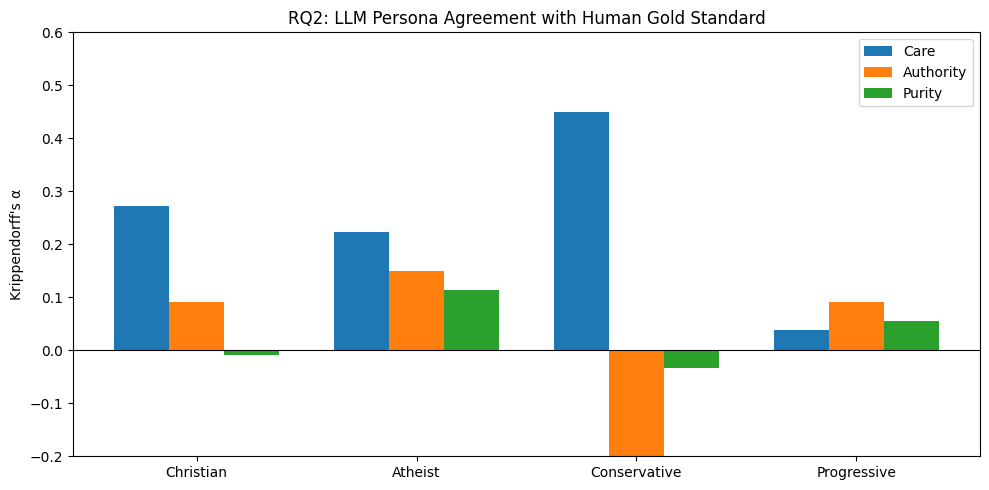

In [5]:
# Alpha comparison across personas and foundations
personas = list(CONDITIONS.keys())
x = np.arange(len(personas))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, f in enumerate(FOUNDATIONS):
    vals = [alpha_results[p][f] for p in personas]
    ax.bar(x + (i - 1) * width, vals, width, label=f)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(personas)
ax.set_ylabel("Krippendorff's α")
ax.set_title("RQ2: LLM Persona Agreement with Human Gold Standard")
ax.legend()
ax.set_ylim(-0.2, 0.6)
plt.tight_layout()
plt.savefig('rq2_alpha_by_persona.png', dpi=150)
plt.show()

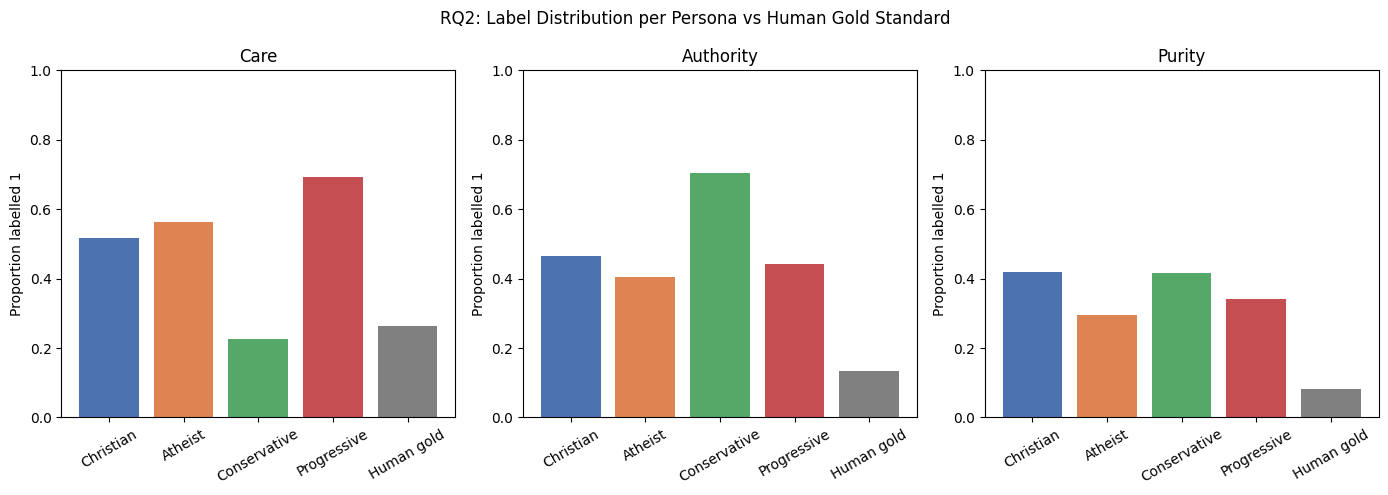

In [6]:
# Label distribution per persona vs human gold
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', 'gray']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, f in enumerate(FOUNDATIONS):
    props = {
        'Christian':    df_christian[f].mean(),
        'Atheist':      df_atheist[f].mean(),
        'Conservative': df_conservative[f].mean(),
        'Progressive':  df_progressive[f].mean(),
        'Human gold':   df_human_bin[df_human_bin['item_id'].isin(shared_ids)][f].mean(),
    }
    axes[i].bar(props.keys(), props.values(), color=colors)
    axes[i].set_title(f)
    axes[i].set_ylabel('Proportion labelled 1')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('RQ2: Label Distribution per Persona vs Human Gold Standard')
plt.tight_layout()
plt.savefig('rq2_label_distribution.png', dpi=150)
plt.show()

## Pairwise Krippendorff's Alpha between opposing personas
Direct comparison between Christian vs Atheist and Conservative vs Progressive.

In [7]:
CROSS_PAIRS = [
    ('Christian',    df_christian,    'Atheist',     df_atheist),
    ('Conservative', df_conservative, 'Progressive', df_progressive),
]

rows_cross = []
for name_a, df_a, name_b, df_b in CROSS_PAIRS:
    row = [f'{name_a} vs {name_b}']
    alphas = []
    for f in FOUNDATIONS:
        val = pairwise_alpha(df_a, df_b, f)
        row.append(f"{val:.3f}" if not np.isnan(val) else "n/a")
        if not np.isnan(val):
            alphas.append(val)
    avg = np.mean(alphas) if alphas else np.nan
    row.append(f"{avg:.3f}" if not np.isnan(avg) else "n/a")
    rows_cross.append(row)

print("TABLE: Pairwise Krippendorff's Alpha between opposing personas")
print(tabulate(rows_cross, headers=['Pair'] + FOUNDATIONS + ['Avg α'], tablefmt='rounded_outline'))

TABLE: Pairwise Krippendorff's Alpha between opposing personas
╭─────────────────────────────┬────────┬─────────────┬──────────┬─────────╮
│ Pair                        │   Care │   Authority │   Purity │   Avg α │
├─────────────────────────────┼────────┼─────────────┼──────────┼─────────┤
│ Christian vs Atheist        │  0.807 │       0.774 │    0.702 │   0.761 │
│ Conservative vs Progressive │  0.062 │       0.43  │    0.48  │   0.324 │
╰─────────────────────────────┴────────┴─────────────┴──────────┴─────────╯


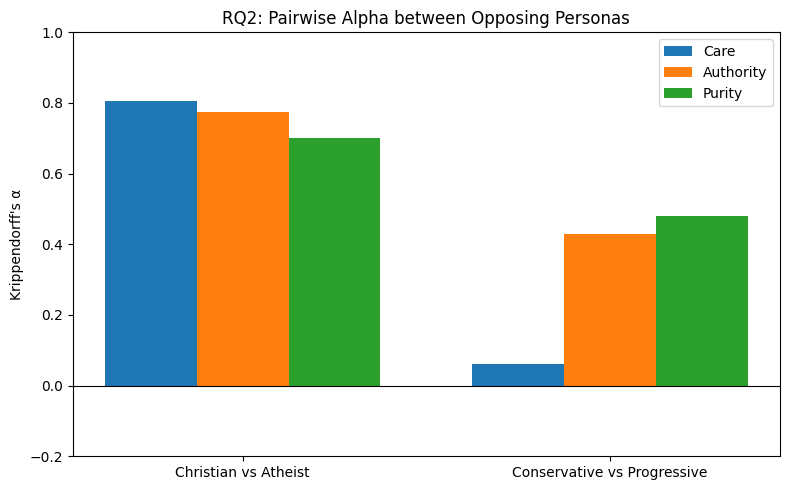

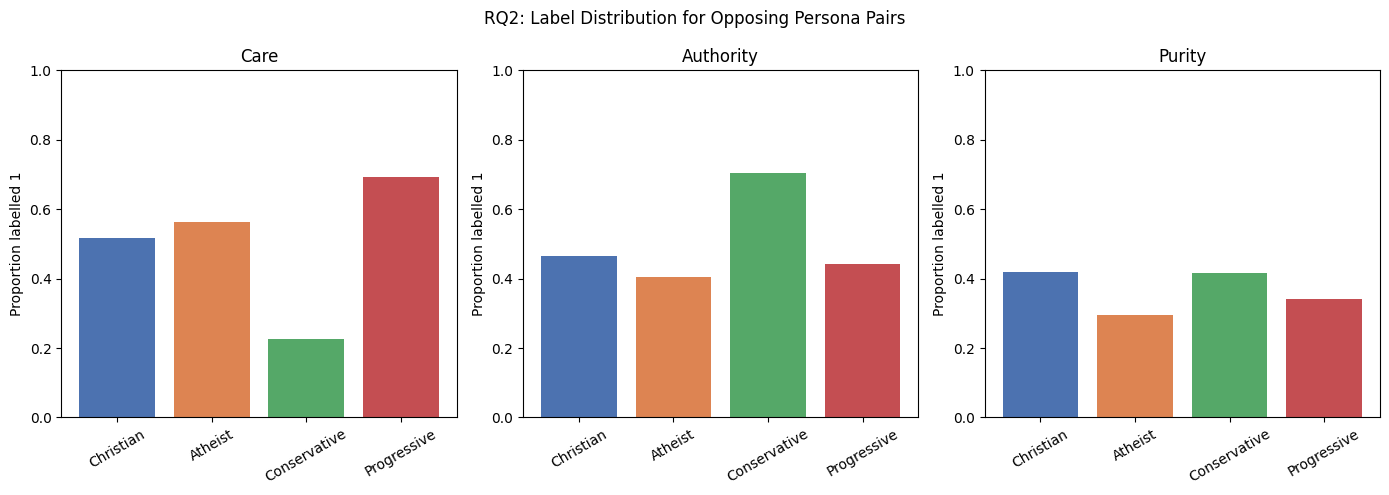

In [8]:
# Alpha bar chart: Christian vs Atheist and Conservative vs Progressive
pair_labels = ['Christian vs Atheist', 'Conservative vs Progressive']
cross_alpha_results = {}
for name_a, df_a, name_b, df_b in CROSS_PAIRS:
    label = f'{name_a} vs {name_b}'
    cross_alpha_results[label] = {f: pairwise_alpha(df_a, df_b, f) for f in FOUNDATIONS}

x = np.arange(len(pair_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, f in enumerate(FOUNDATIONS):
    vals = [cross_alpha_results[p][f] for p in pair_labels]
    ax.bar(x + (i - 1) * width, vals, width, label=f)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pair_labels)
ax.set_ylabel("Krippendorff's α")
ax.set_title("RQ2: Pairwise Alpha between Opposing Personas")
ax.legend()
ax.set_ylim(-0.2, 1.0)
plt.tight_layout()
plt.savefig('rq2_cross_persona_alpha.png', dpi=150)
plt.show()

# Label distribution: just the two pairs side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, f in enumerate(FOUNDATIONS):
    props = {
        'Christian':    df_christian[f].mean(),
        'Atheist':      df_atheist[f].mean(),
        'Conservative': df_conservative[f].mean(),
        'Progressive':  df_progressive[f].mean(),
    }
    axes[i].bar(props.keys(), props.values(), color=colors)
    axes[i].set_title(f)
    axes[i].set_ylabel('Proportion labelled 1')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('RQ2: Label Distribution for Opposing Persona Pairs')
plt.tight_layout()
plt.savefig('rq2_cross_persona_distribution.png', dpi=150)
plt.show()